In [ ]:
!apt-get install -y ffmpeg
!pip install tqdm

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from __future__ import annotations

import os
import random

from tqdm import tqdm
import soundfile as sf
from pathlib import Path
from typing import Optional
from multiprocessing import Pool, cpu_count

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# -*- coding: utf-8 -*-
"""
MyST Speaker Inventory Builder

This script constructs file-level metadata and speaker-level inventory
for the MyST portion of the dataset construction protocol.

Current scope
-------------
This script is designed for the minor speaker pool derived from MyST audio.

Main outputs
------------
1. File metadata:
   One row per available audio file.

2. Speaker inventory:
   One row per speaker, including:
   - dataset_source
   - speaker_id
   - source_age
   - mapped_age
   - gender
   - total_raw_duration_sec
   - num_files
   - role

Notes
-----
- This script operates before VAD-based preprocessing and segmentation.
- It uses raw file durations only.
- MyST does not provide explicit age labels or speaker metadata here.
- Therefore:
    * source_age is set to None
    * mapped_age is set to "minor"
    * gender is set to None
- The original dataset split is not used here, since the final split
  will be created later at the project level.
"""

random.seed(42)


# =========================================================
# Configuration
# =========================================================

MYST_ROOT = Path("/content/drive/MyDrive/age verification/data/myst/data")

FILE_METADATA_OUT = Path("/content/drive/MyDrive/age verification/data/myst/myst_file_metadata.csv")
SPEAKER_INVENTORY_OUT = Path("/content/drive/MyDrive/age verification/data/myst/myst_speaker_inventory.csv")
TEMP_DURATIONS_OUT = Path("/content/drive/MyDrive/age verification/data/myst/durations_progress.csv")

DATASET_SOURCE = "myst"
MIN_TOTAL_DURATION_SEC = 12.0
SAVE_EVERY = 500


# =========================================================
# File Scanning
# =========================================================
def scan_myst_audio_files(myst_root_dir: Path) -> pd.DataFrame:
    """
    Scan the MyST directory and collect file-level metadata.

    Expected structure
    ------------------
    <root>/<partition>/<student_id>/<session_id>/<file>.flac

    Parameters
    ----------
    myst_root_dir : Path
        Root directory of the MyST dataset.

    Returns
    -------
    pd.DataFrame
        DataFrame containing:
        - speaker_id
        - session_id
        - file_name
        - file_path
        - full_path
        - source_age
        - mapped_age
        - gender
    """
    records = []

    for root, _, files in os.walk(myst_root_dir):
        for file_name in files:
            if not file_name.lower().endswith(".flac"):
                continue

            full_path = Path(root) / file_name

            try:
                rel_path = full_path.relative_to(myst_root_dir)
                parts = rel_path.parts
            except ValueError:
                continue

            # Expected:
            # parts[0] = partition
            # parts[1] = speaker_id (student_id)
            # parts[2] = session_id
            if len(parts) >= 4:
              source_partition = parts[0]   # development / train / test
              speaker_id = parts[1]
              session_id = parts[2]
            else:
              source_partition = "unknown"
              speaker_id = "unknown"
              session_id = "unknown"

            records.append(
                {
                    "speaker_id": str(speaker_id).strip(),
                    "session_id": str(session_id).strip(),
                    "file_name": file_name,
                    "file_path": str(rel_path),
                    "full_path": str(full_path),
                    "source_partition": source_partition,
                    "source_age": None,
                    "mapped_age": "minor",
                    "gender": None,
                }
            )

    df = pd.DataFrame(records)
    return df


# =========================================================
# Duration Utilities
# =========================================================
def get_duration_sec(audio_path: str) -> Optional[float]:
    """
    Read audio duration in seconds using soundfile metadata.

    Parameters
    ----------
    audio_path : str
        Path to the audio file.

    Returns
    -------
    float or None
        Duration in seconds if successful, otherwise None.
    """
    try:
        info = sf.info(audio_path)
        return round(info.frames / info.samplerate, 3)
    except Exception:
        return None


def load_saved_durations(progress_path: Path) -> pd.DataFrame:
    """
    Load previously saved duration progress if available.

    Parameters
    ----------
    progress_path : Path
        CSV file used for storing duration extraction progress.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - full_path
        - duration_sec
    """
    if progress_path.exists():
        durations_df = pd.read_csv(progress_path)
    else:
        durations_df = pd.DataFrame(columns=["full_path", "duration_sec"])

    durations_df["full_path"] = durations_df["full_path"].astype(str)
    return durations_df


def get_duration_record(path: str) -> dict:
    """
    Create a duration record for a single audio file.

    Parameters
    ----------
    path : str
        Full path to the audio file.

    Returns
    -------
    dict
        Contains:
        - full_path
        - duration_sec
    """
    return {
        "full_path": path,
        "duration_sec": get_duration_sec(path)
    }

def extract_missing_durations(
    file_df: pd.DataFrame,
    progress_path: Path,
    save_every: int = SAVE_EVERY,
) -> pd.DataFrame:
    """
    Extract durations for files that have not yet been processed.

    Progress is saved incrementally to support resuming interrupted runs.

    Parameters
    ----------
    file_df : pd.DataFrame
        File metadata DataFrame containing full_path.
    progress_path : Path
        Output CSV path for duration progress.
    save_every : int
        Save progress every N files.

    Returns
    -------
    pd.DataFrame
        DataFrame with:
        - full_path
        - duration_sec
    """
    durations_df = load_saved_durations(progress_path)
    done_paths = set(durations_df["full_path"].astype(str))

    file_df = file_df.copy()
    file_df["full_path"] = file_df["full_path"].astype(str)

    to_process = file_df[~file_df["full_path"].isin(done_paths)].copy()

    print(f"Already processed durations: {len(done_paths)}")
    print(f"Remaining files to process: {len(to_process)}")

    if len(to_process) == 0:
        return durations_df

    batch_results = []

    paths = to_process["full_path"].tolist()
    n_workers = cpu_count()

    with Pool(processes=n_workers) as pool:
        for i, result in enumerate(
            tqdm(pool.imap(get_duration_record, paths, chunksize=128),
                total=len(paths),
                desc="Processing audio"),
            start=1
        ):
            batch_results.append(result)

            if i % save_every == 0:
                batch_df = pd.DataFrame(batch_results)

                if durations_df.empty:
                    durations_df = batch_df.copy()
                else:
                    durations_df = pd.concat([durations_df, batch_df], ignore_index=True)

                durations_df = durations_df.drop_duplicates(subset=["full_path"], keep="last")
                progress_path.parent.mkdir(parents=True, exist_ok=True)
                durations_df.to_csv(progress_path, index=False)
                batch_results = []

    if batch_results:
        batch_df = pd.DataFrame(batch_results)

        if durations_df.empty:
            durations_df = batch_df.copy()
        else:
            durations_df = pd.concat([durations_df, batch_df], ignore_index=True)

        durations_df = durations_df.drop_duplicates(subset=["full_path"], keep="last")
        progress_path.parent.mkdir(parents=True, exist_ok=True)
        durations_df.to_csv(progress_path, index=False)

    return durations_df


# =========================================================
# Output Builders
# =========================================================
def build_file_metadata(
    file_df: pd.DataFrame,
    durations_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construct file-level metadata for MyST audio files.

    Parameters
    ----------
    file_df : pd.DataFrame
        Scanned file metadata.
    durations_df : pd.DataFrame
        Duration table.

    Returns
    -------
    pd.DataFrame
        File-level metadata table.
    """
    durations_df = durations_df.copy()
    durations_df["full_path"] = durations_df["full_path"].astype(str)

    file_metadata_df = file_df.merge(durations_df, on="full_path", how="left")

    file_metadata_df = file_metadata_df[
        [
            "speaker_id",
            "session_id",
            "file_name",
            "source_partition",
            "source_age",
            "mapped_age",
            "gender",
            "duration_sec",
            "file_path",
            "full_path",
        ]
    ].copy()

    return file_metadata_df


def build_speaker_inventory(file_metadata_df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct speaker-level inventory required by the dataset protocol.

    Output columns
    --------------
    - dataset_source
    - speaker_id
    - source_age
    - mapped_age
    - gender
    - total_raw_duration_sec
    - num_files
    """
    speaker_inventory_df = (
        file_metadata_df
        .groupby("speaker_id", as_index=False)
        .agg(
            source_age=("source_age", "first"),
            mapped_age=("mapped_age", "first"),
            gender=("gender", "first"),
            total_raw_duration_sec=("duration_sec", "sum"),
            num_files=("file_path", "count"),
        )
    )

    speaker_inventory_df["dataset_source"] = DATASET_SOURCE
    speaker_inventory_df["total_raw_duration_sec"] = speaker_inventory_df["total_raw_duration_sec"].round(3)

    speaker_inventory_df = speaker_inventory_df[
        [
            "dataset_source",
            "speaker_id",
            "source_age",
            "mapped_age",
            "gender",
            "total_raw_duration_sec",
            "num_files",
        ]
    ].copy()

    return speaker_inventory_df


# =========================================================
# Inventory Role Assignment
# =========================================================
def assign_inventory_role(total_raw_duration_sec: float) -> str:
    """
    Assign a preliminary speaker role based on total raw duration.

    Rules
    -----
    < 12 sec   -> drop
    12-1000 sec  -> real_candidates
    > 1000 sec   -> randomly assign to spoof_targets or backup
    """
    if pd.isna(total_raw_duration_sec) or total_raw_duration_sec < 12:
        return "drop"
    if total_raw_duration_sec <= 1000:
        return "real_candidates"

    return random.choice(["spoof_targets", "backup"])


def filter_inventory_by_duration(
    speaker_inventory_df: pd.DataFrame,
    min_total_duration_sec: float = MIN_TOTAL_DURATION_SEC,
) -> pd.DataFrame:
    """
    Remove speakers with insufficient total raw duration.

    Parameters
    ----------
    speaker_inventory_df : pd.DataFrame
        Speaker inventory table.
    min_total_duration_sec : float
        Minimum required total raw duration.

    Returns
    -------
    pd.DataFrame
        Filtered speaker inventory.
    """
    return speaker_inventory_df[
        speaker_inventory_df["total_raw_duration_sec"] >= min_total_duration_sec
    ].copy()


# =========================================================
# Main
# =========================================================
def main() -> None:
    """
    Run the full MyST inventory construction pipeline.
    """
    print("\n" + "=" * 60)
    print("MYST INVENTORY PIPELINE")
    print("=" * 60)

    print("[1/5] Scanning MyST audio files...")
    file_df = scan_myst_audio_files(MYST_ROOT)
    total_files = len(file_df)

    if total_files == 0:
        print("No files found. Exiting.")
        return

    print("[2/5] Extracting durations with resume support...")
    durations_df = extract_missing_durations(
        file_df=file_df,
        progress_path=TEMP_DURATIONS_OUT,
        save_every=SAVE_EVERY,
    )

    print("[3/5] Building file metadata...")
    file_metadata_df = build_file_metadata(file_df, durations_df)

    missing_duration = file_metadata_df["duration_sec"].isna().sum()

    print("[4/5] Saving file metadata...")
    FILE_METADATA_OUT.parent.mkdir(parents=True, exist_ok=True)
    file_metadata_df.to_csv(FILE_METADATA_OUT, index=False)

    print("[5/5] Building speaker inventory...")
    speaker_inventory_df = build_speaker_inventory(file_metadata_df)
    speaker_inventory_df = speaker_inventory_df.sort_values("speaker_id").reset_index(drop=True)
    speaker_inventory_df["role"] = speaker_inventory_df["total_raw_duration_sec"].apply(assign_inventory_role)

    # ===== BEFORE FILTER =====
    role_counts_before = speaker_inventory_df["role"].value_counts(dropna=False)
    role_counts_before.index.name = None

    # ===== FILTER =====
    speaker_inventory_df = filter_inventory_by_duration(
        speaker_inventory_df=speaker_inventory_df,
        min_total_duration_sec=MIN_TOTAL_DURATION_SEC,
    )

    print("Saving speaker inventory...")
    SPEAKER_INVENTORY_OUT.parent.mkdir(parents=True, exist_ok=True)
    speaker_inventory_df.to_csv(SPEAKER_INVENTORY_OUT, index=False)

    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Total files                : {total_files}")
    print(f"Missing duration rows      : {missing_duration}")
    print(f"File metadata saved to     : {FILE_METADATA_OUT}")
    print(f"Speaker inventory saved to : {SPEAKER_INVENTORY_OUT}")

    print("\n" + "=" * 60)
    print("ROLE DISTRIBUTION")
    print("=" * 60)
    print(role_counts_before.to_string())


if __name__ == "__main__":
    main()


MYST INVENTORY PIPELINE
[1/5] Scanning MyST audio files...
[2/5] Extracting durations with resume support...
Already processed durations: 227570
Remaining files to process: 0
[3/5] Building file metadata...
[4/5] Saving file metadata...
[5/5] Building speaker inventory...
Saving speaker inventory...

SUMMARY
Total files                : 227570
Missing duration rows      : 0
File metadata saved to     : /content/drive/MyDrive/age verification/data/myst/myst_file_metadata.csv
Speaker inventory saved to : /content/drive/MyDrive/age verification/data/myst/myst_speaker_inventory.csv

ROLE DISTRIBUTION
real_candidates    692
spoof_targets      339
backup             333
drop                 7


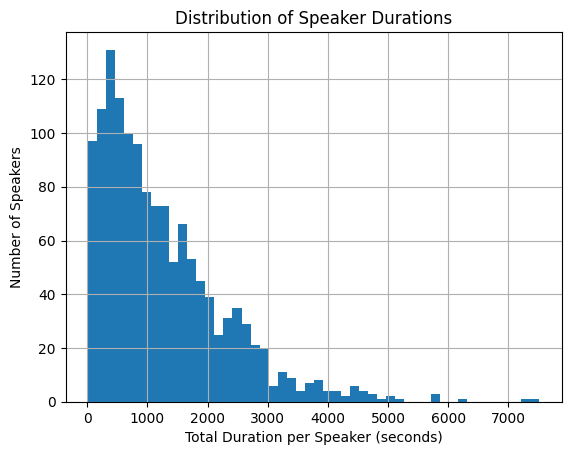

In [ ]:
MYST_PATH = "/content/drive/MyDrive/age verification/data/myst/myst_speaker_inventory.csv"

df = pd.read_csv(MYST_PATH)

plt.figure()
df["total_raw_duration_sec"].hist(bins=50)

plt.xlabel("Total Duration per Speaker (seconds)")
plt.ylabel("Number of Speakers")
plt.title("Distribution of Speaker Durations")

plt.show()

In [ ]:
low = 12
high = 1000

real_test = df[
    (df["total_raw_duration_sec"] >= low) &
    (df["total_raw_duration_sec"] <= high)
]

print(f"Real count: {len(real_test)}")
print(f"Percentage: {len(real_test)/len(df)*100:.2f}%")

Real count: 692
Percentage: 50.73%


In [ ]:
real_test = df[
    (df["total_raw_duration_sec"] >= 12) &
    (df["total_raw_duration_sec"] <= 90)
]
print(f"Real count: {len(real_test)}")
print(f"Percentage: {len(real_test)/len(df)*100:.2f}%")

Real count: 41
Percentage: 3.01%
